# 06｜混淆矩陣、閾值與 ROC

第三週主線；對應 `03_分類與模型評估.md` 的手算活動、PR／ROC、資源限制。約 25 分鐘。目標：連結分數、決策、成本與排序品質。

## 來源與改編界線
- [leonjyentub/MachineLearning2025 / 01_ROC_AUC.py](https://github.com/leonjyentub/MachineLearning2025/blob/3da2cb56b9efd17d7cd34602589f392554b40603/01_ROC_AUC.py)：原始 20 筆 y_true 與兩組 scores、calculate_roc_auc
- [ageron/handson-mlp / 03_classification.ipynb](https://github.com/ageron/handson-mlp/blob/47eba45aacc85feae51ba7db68dd1ca66cb25e0a/03_classification.ipynb)：儲存格 28–74 的 accuracy、CM、precision/recall、threshold、ROC

**本課程修改／補充：** 保留教師原始 20 筆陣列；修正 ROC 閾值順序並補上 (0,0)，與 sklearn 和成對排序公式交叉驗證。另加入與本課程投影片一致的 8 筆自編案例及可動閾值。

來源固定至上述 commit；原檔保留於 `../upstream/`，逐檔 SHA-256 見 `../upstream/manifest.json`。Géron 程式依 Apache-2.0 改編，授權原文保留。儲存格索引從 0 起算。圖表與數值是本 Notebook 重跑結果，不能直接當成書中成效。

從第一格依序執行；各本可獨立重跑。Python 環境與資料準備見 [操作說明](../README.md)。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlcourse.common import ROOT, DATA, OUT, SEED, FAST, setup, savefig, report, data_path
setup()

{'profile': 'fast',
 'seed': 42,
 'data': '/Users/leonjye/Documents/MacProject/MLCourse2026/programs/data'}

In [2]:
from sklearn.metrics import (confusion_matrix,precision_score,recall_score,f1_score,accuracy_score,
    roc_curve,roc_auc_score,precision_recall_curve,average_precision_score)
y=np.array([1,0,1,1,0,0,1,0])
scores=np.array([.95,.85,.8,.7,.6,.4,.3,.1])
def threshold_row(y,scores,threshold):
    pred=scores>=threshold
    tn,fp,fn,tp=confusion_matrix(y,pred,labels=[0,1]).ravel()
    return {'threshold':threshold,'TP':tp,'FP':fp,'FN':fn,'TN':tn,
            'precision':precision_score(y,pred,zero_division=0),'recall':recall_score(y,pred),
            'F1':f1_score(y,pred,zero_division=0),'flagged':int(pred.sum()),'cost_FP_plus_4FN':int(fp+4*fn)}
table=pd.DataFrame([threshold_row(y,scores,t) for t in [.8,.5,.2]])
assert table[['TP','FP','FN','TN']].values.tolist()==[[2,1,2,3],[3,2,1,2],[4,3,0,1]]
assert table.cost_FP_plus_4FN.tolist()==[9,6,3]
assert np.isclose(roc_auc_score(y,scores),.6875)
table

,threshold,TP,FP,FN,TN,precision,recall,F1,flagged,cost_FP_plus_4FN
0,0.8,2,1,2,3,0.666667,0.50,0.571429,3,9
1,0.5,3,2,1,2,0.600000,0.75,0.666667,5,6
2,0.2,4,3,0,1,0.571429,1.00,0.727273,7,3


## 1. 降低閾值，不是免費提高 recall

此例每個漏判成本 4、誤報成本 1；每天最多檢查 5 筆。在三個候選中，0.2 成本低卻超出容量；0.5 是可行候選裡成本最低者。這是自編教學政策，不能把成本數字當成真實業務資料。

分母為 0 的 precision 在下方以 0 作計算政策；它代表「沒有預測正例，precision 未定義而以 0 填入」，不是實際觀察的零命中率。

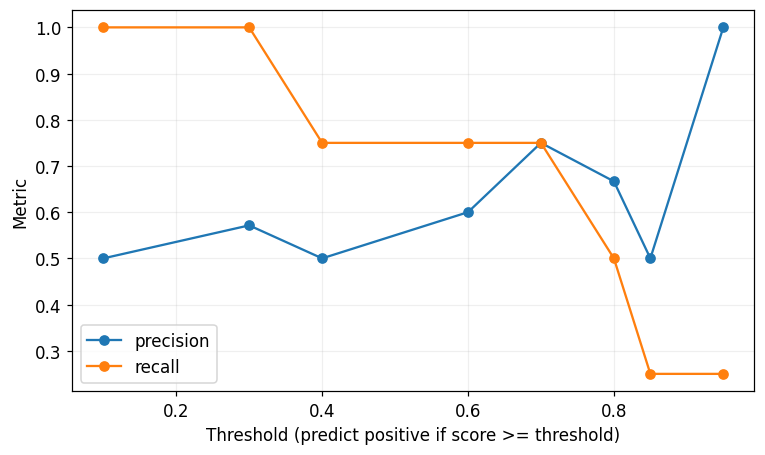

Chosen candidate under capacity=5: {'threshold': 0.5, 'TP': 3.0, 'FP': 2.0, 'FN': 1.0, 'TN': 2.0, 'precision': 0.6, 'recall': 0.75, 'F1': 0.6666666666666666, 'flagged': 5.0, 'cost_FP_plus_4FN': 6.0}


In [3]:
feasible=table[table.flagged<=5]
chosen=feasible.loc[feasible.cost_FP_plus_4FN.idxmin()]
assert chosen.threshold==.5
thresholds=np.r_[np.inf,np.unique(scores)[::-1]]
curve=pd.DataFrame([threshold_row(y,scores,t) for t in thresholds])
finite=curve[np.isfinite(curve.threshold)]
plt.plot(finite.threshold,finite.precision,'o-',label='precision')
plt.plot(finite.threshold,finite.recall,'o-',label='recall')
plt.xlabel('Threshold (predict positive if score >= threshold)');plt.ylabel('Metric');plt.legend()
savefig('06_threshold_tradeoff')
print('Chosen candidate under capacity=5:',chosen.to_dict())

## 2. 原 ROC 程式的方向問題
沿遞增閾值會從 (1,1) 走向 (0,0)，此時對 FPR 做梯形積分可能為負。改以 `inf → 高分 → 低分` 走完整曲線；同分數一起移動，避免任意打破 ties。

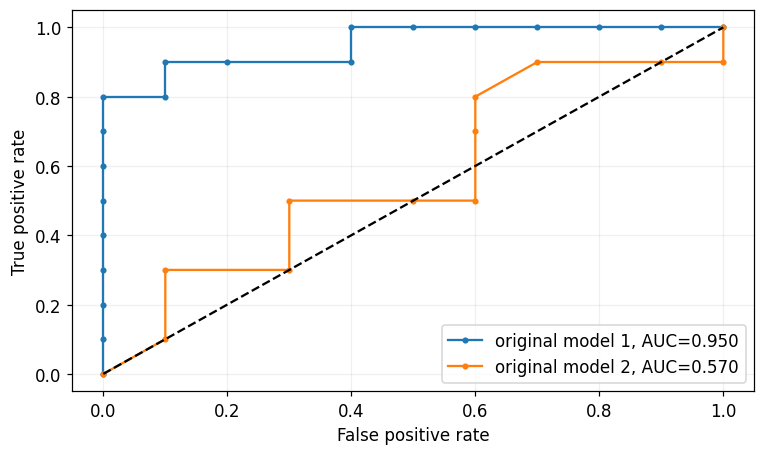

,model,AUC,pairwise_AUC,accuracy_at_0.5
0,original model 1,0.95,0.95,0.90
1,original model 2,0.57,0.57,0.45


In [4]:
y20=np.array([0,0,1,1,0,1,0,1,0,1,0,1,1,0,1,0,0,1,0,1])
s1=np.array([.1,.4,.35,.8,.2,.6,.3,.9,.4,.7,.15,.85,.5,.25,.65,.55,.45,.75,.05,.95])
s2=np.array([.45,.55,.52,.28,.51,.49,.46,.54,.53,.47,.50,.52,.48,.51,.49,.53,.47,.54,.46,.55])
def manual_roc(y,score):
    y=np.asarray(y);score=np.asarray(score)
    if not (np.any(y==0) and np.any(y==1)):
        raise ValueError('ROC requires both negative and positive examples')
    thresholds=np.r_[np.inf,np.unique(score)[::-1]]
    points=[]
    for threshold in thresholds:
        pred=score>=threshold
        tp=np.sum(pred & (y==1));fp=np.sum(pred & (y==0))
        points.append((fp/np.sum(y==0),tp/np.sum(y==1)))
    return np.array(points),thresholds
rows=[]
for name,score in [('original model 1',s1),('original model 2',s2)]:
    points,thresholds=manual_roc(y20,score)
    auc=np.trapezoid(points[:,1],points[:,0])
    positive=score[y20==1][:,None];negative=score[y20==0][None,:]
    ranking=np.mean((positive>negative)+.5*(positive==negative))
    assert np.allclose(points[[0,-1]],[[0,0],[1,1]])
    assert np.all(np.diff(points[:,0])>=0)
    assert np.isclose(auc,roc_auc_score(y20,score)) and np.isclose(auc,ranking)
    rows.append({'model':name,'AUC':auc,'pairwise_AUC':ranking,
                 'accuracy_at_0.5':accuracy_score(y20,score>=.5)})
    plt.plot(points[:,0],points[:,1],marker='.',label=f'{name}, AUC={auc:.3f}')
plt.plot([0,1],[0,1],'k--');plt.xlabel('False positive rate');plt.ylabel('True positive rate');plt.legend()
savefig('06_original_roc_corrected')
roc_results=pd.DataFrame(rows)
roc_results

## 3. PR 與 ROC 回答不同問題

PR 的 precision 與盛行率相關；ROC 的 FPR 分母是負例，類別高度不平衡時需要同時看 PR 及實際數量。下圖使用 8 筆示例，因此 PR 的 prevalence 參考值為 0.5。Average Precision（AP）以 recall 增量加權 precision，並非把 PR 點做梯形積分；不把兩者混稱。

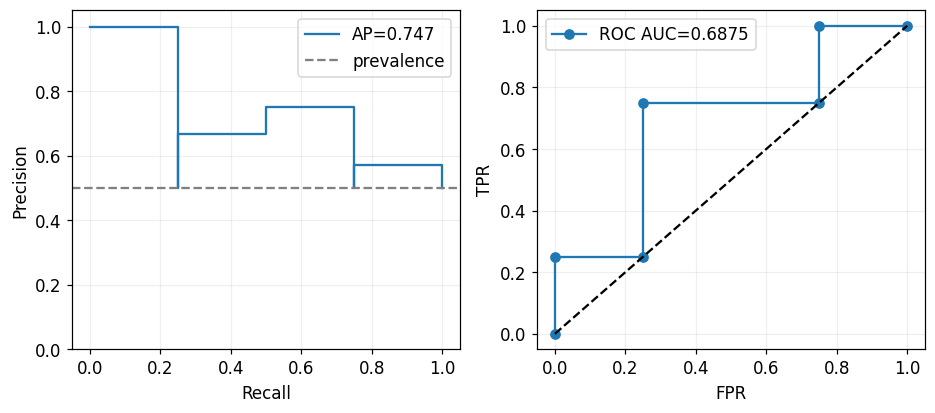

In [5]:
p,r,_=precision_recall_curve(y,scores)
fpr,tpr,_=roc_curve(y,scores)
fig,axes=plt.subplots(1,2,figsize=(10,4))
axes[0].step(r,p,where='post',label=f'AP={average_precision_score(y,scores):.3f}')
axes[0].axhline(y.mean(),ls='--',color='grey',label='prevalence')
axes[0].set(xlabel='Recall',ylabel='Precision',ylim=(0,1.05));axes[0].legend()
axes[1].plot(fpr,tpr,'o-',label=f'ROC AUC={roc_auc_score(y,scores):.4f}')
axes[1].plot([0,1],[0,1],'k--');axes[1].set(xlabel='FPR',ylabel='TPR');axes[1].legend()
savefig('06_pr_roc')
report('threshold_metrics',{'toy_auc':roc_auc_score(y,scores),'toy_AP':average_precision_score(y,scores),
                           'selected_threshold':float(chosen.threshold),'original_models':roc_results.to_dict('records')})

## 4. 可選互動：先預測混淆矩陣，再移動滑桿
Jupyter 中可互動；靜態 HTML／未安裝 widget 前端時，使用上方固定表格。只用這 8 筆玩具資料，不涉及真實 test 調參。

In [6]:
import ipywidgets as widgets
from IPython.display import display
def inspect_threshold(threshold=.5):
    row=threshold_row(y,scores,threshold)
    display(pd.DataFrame([row]))
    fig,ax=plt.subplots(figsize=(5,2))
    ax.scatter(scores,np.zeros(len(y)),c=y,cmap='coolwarm',s=90,vmin=0,vmax=1)
    for i,s in enumerate(scores): ax.annotate(str(i+1),(s,.01))
    ax.axvline(threshold,color='k',ls='--');ax.set(xlim=(0,1),ylim=(-.1,.1),yticks=[],xlabel='Score: blue=0, red=1')
    plt.show()
widgets.interactive(inspect_threshold,threshold=widgets.FloatSlider(value=.5,min=0,max=1,step=.05))

interactive(children=(FloatSlider(value=0.5, description='threshold', max=1.0, step=0.05), Output()), _dom_cla…

## 練習與參考答案

- 分數相同時 AUC 的排序貢獻為何？**0.5。**
- 同一排序把所有分數加 10，AUC 變嗎？**不變，但固定 0.5 閾值的決策可能完全不同。**
- 要部署「precision ≥ 90%」的閾值，在哪裡決定？**validation 或開發集預測；再以未使用的 test 評估，不能保證部署後仍維持 90%。**